In [1]:
# install BLADE with !pip install iohblade

from iohblade.loggers import ExperimentLogger
from iohblade.plots import plot_convergence, plot_experiment_CEG, plot_boxplot_fitness_hue
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json


def plot_landscape(row, bounds=(-5, 5), res=200):
    """
    row  : one row of the dataframe (df.loc[idx] or df.iloc[idx])
    bounds: (low, high) tuple applied to both axes
    res   : grid resolution per axis
    """
    # Re-create the callable from the code string
    ns = {}
    exec(row["code"], ns)                      # defines class with same name as row["name"]
    f   = getattr(ns[row["name"]](dim=2), "f")      # instantiate & grab its .f method

    # Grid
    x = np.linspace(bounds[0], bounds[1], res)
    y = np.linspace(bounds[0], bounds[1], res)
    X, Y = np.meshgrid(x, y)
    pts   = np.stack([X.ravel(), Y.ravel()], axis=1)
    Z     = np.apply_along_axis(f, 1, pts).reshape(X.shape)   # robust fallback

    # Plot
    fig, ax = plt.subplots(figsize=(6, 5))
    cs = ax.contourf(X, Y, Z, levels=50, cmap="viridis")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"Landscape of {row['name']}")
    plt.colorbar(cs, ax=ax, label="f(x)")
    plt.tight_layout()
    return fig, ax

logger = ExperimentLogger('../results/ELA_novelty_4_oai', True)
# logger.add_read_dir('../results/kerneltuner-o4')
# logger.add_read_dir('../results/kerneltuner-o4-no-info')

/local/bodasap/BLADE/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
methods, problems = logger.get_methods_problems()
print(methods)
print(problems)
len(problems)



['LLaMEA-multi-llm']
['Separable_Homogeneous', 'Separable', 'Basins', 'GlobalLocal', 'NOT Homogeneous_Multimodality', 'GlobalLocal_Multimodality', 'Multimodality_Basins', 'NOT Basins', 'GlobalLocal_Homogeneous', 'NOT Homogeneous_GlobalLocal', 'NOT Basins_Multimodality', 'Multimodality_Homogeneous', 'NOT Homogeneous', 'NOT Basins_GlobalLocal', 'NOT Homogeneous_Separable', 'Separable_GlobalLocal', 'GlobalLocal_Basins', 'NOT Basins_Separable', 'Separable_Multimodality', 'Multimodality', 'Separable_Basins', 'Basins_Homogeneous', 'Homogeneous']


23

<>:45: SyntaxWarning: invalid escape sequence '\h'
<>:45: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_3811913/2357721495.py:45: SyntaxWarning: invalid escape sequence '\h'
  ax.set_ylabel("Percentage with $\hat{F} > 0.5$", fontsize=14)


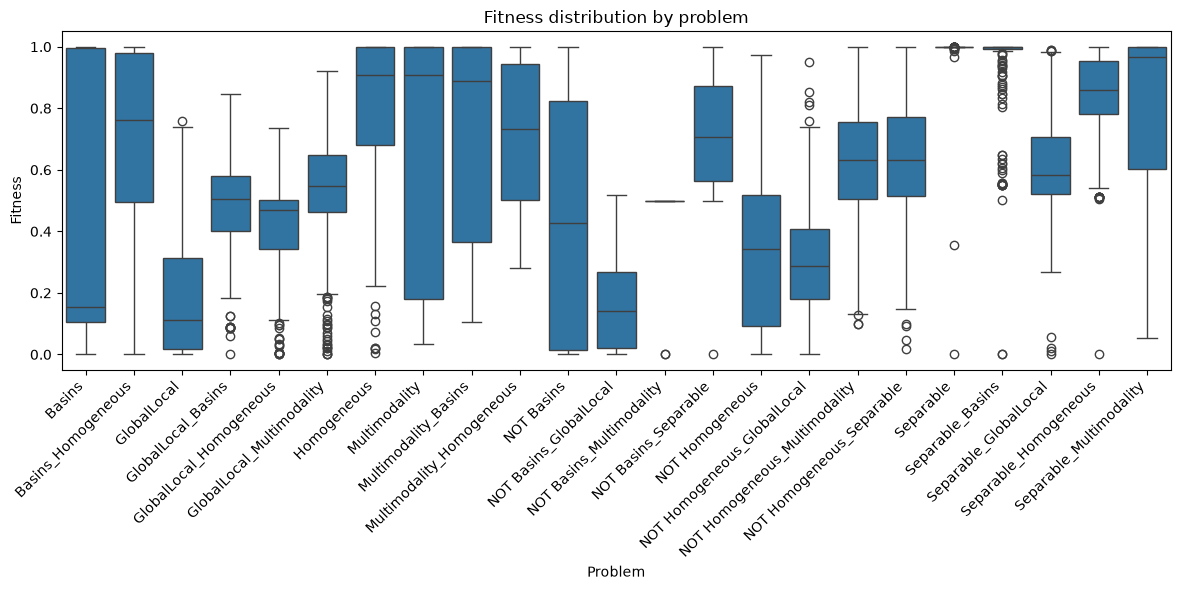

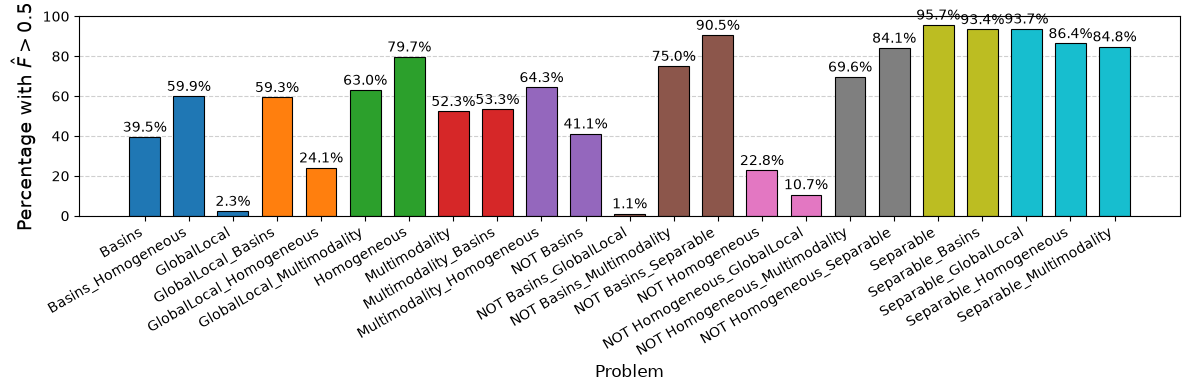

In [3]:
#plot_convergence(logger, metric="fitness", save=False, budget=100)
#plot_boxplot_fitness_hue(logger)

methods, problems = logger.get_methods_problems()
#sort problems by alphabetical order
problems = sorted(problems)

dfs = []
for problem in problems:
    data = logger.get_problem_data(problem_name=problem)
    data = data[data['fitness'] < 1.0001]
    # print if the length of the data is smaller than 11
    if len(data) < 11:
        print(f"Skipped: Problem: {problem}, data points: {len(data)}")
    else:
        data = data.assign(problem_name=str(problem))
        dfs.append(data[["problem_name", "fitness"]])

if len(dfs) > 0:
    all_data = pd.concat(dfs, ignore_index=True)
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=all_data, x='problem_name', y='fitness', ax=ax)
    ax.set_title("Fitness distribution by problem")
    ax.set_xlabel("Problem")
    ax.set_ylabel("Fitness")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()  



    # now count the number of landscapes with a fitness above 0.75 per problem and show this as a bar plot
    counts = all_data[all_data['fitness'] > 0.499999].groupby('problem_name').size() / all_data.groupby('problem_name').size() * 100  # percentage

    fig, ax = plt.subplots(figsize=(12, 4))

    # Generate colors from a colormap (tab10 has 10 distinct colors)
    colors = plt.cm.tab10(np.linspace(0, 1, len(counts)))

    # Plot bars with reduced width
    bars = ax.bar(counts.index, counts.values, color=colors, width=0.7, edgecolor='black', linewidth=0.8)

    # Add labels and nicer style
    ax.set_xlabel("Problem", fontsize=12)
    ax.set_ylabel("Percentage with $\hat{F} > 0.5$", fontsize=14)
    ax.set_ylim(0, 100)
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    # Rotate and align x labels
    plt.xticks(rotation=30, ha='right')

    # Optionally add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.1f}%", ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()


Failed on problem NOT Basins_Multimodality: 0


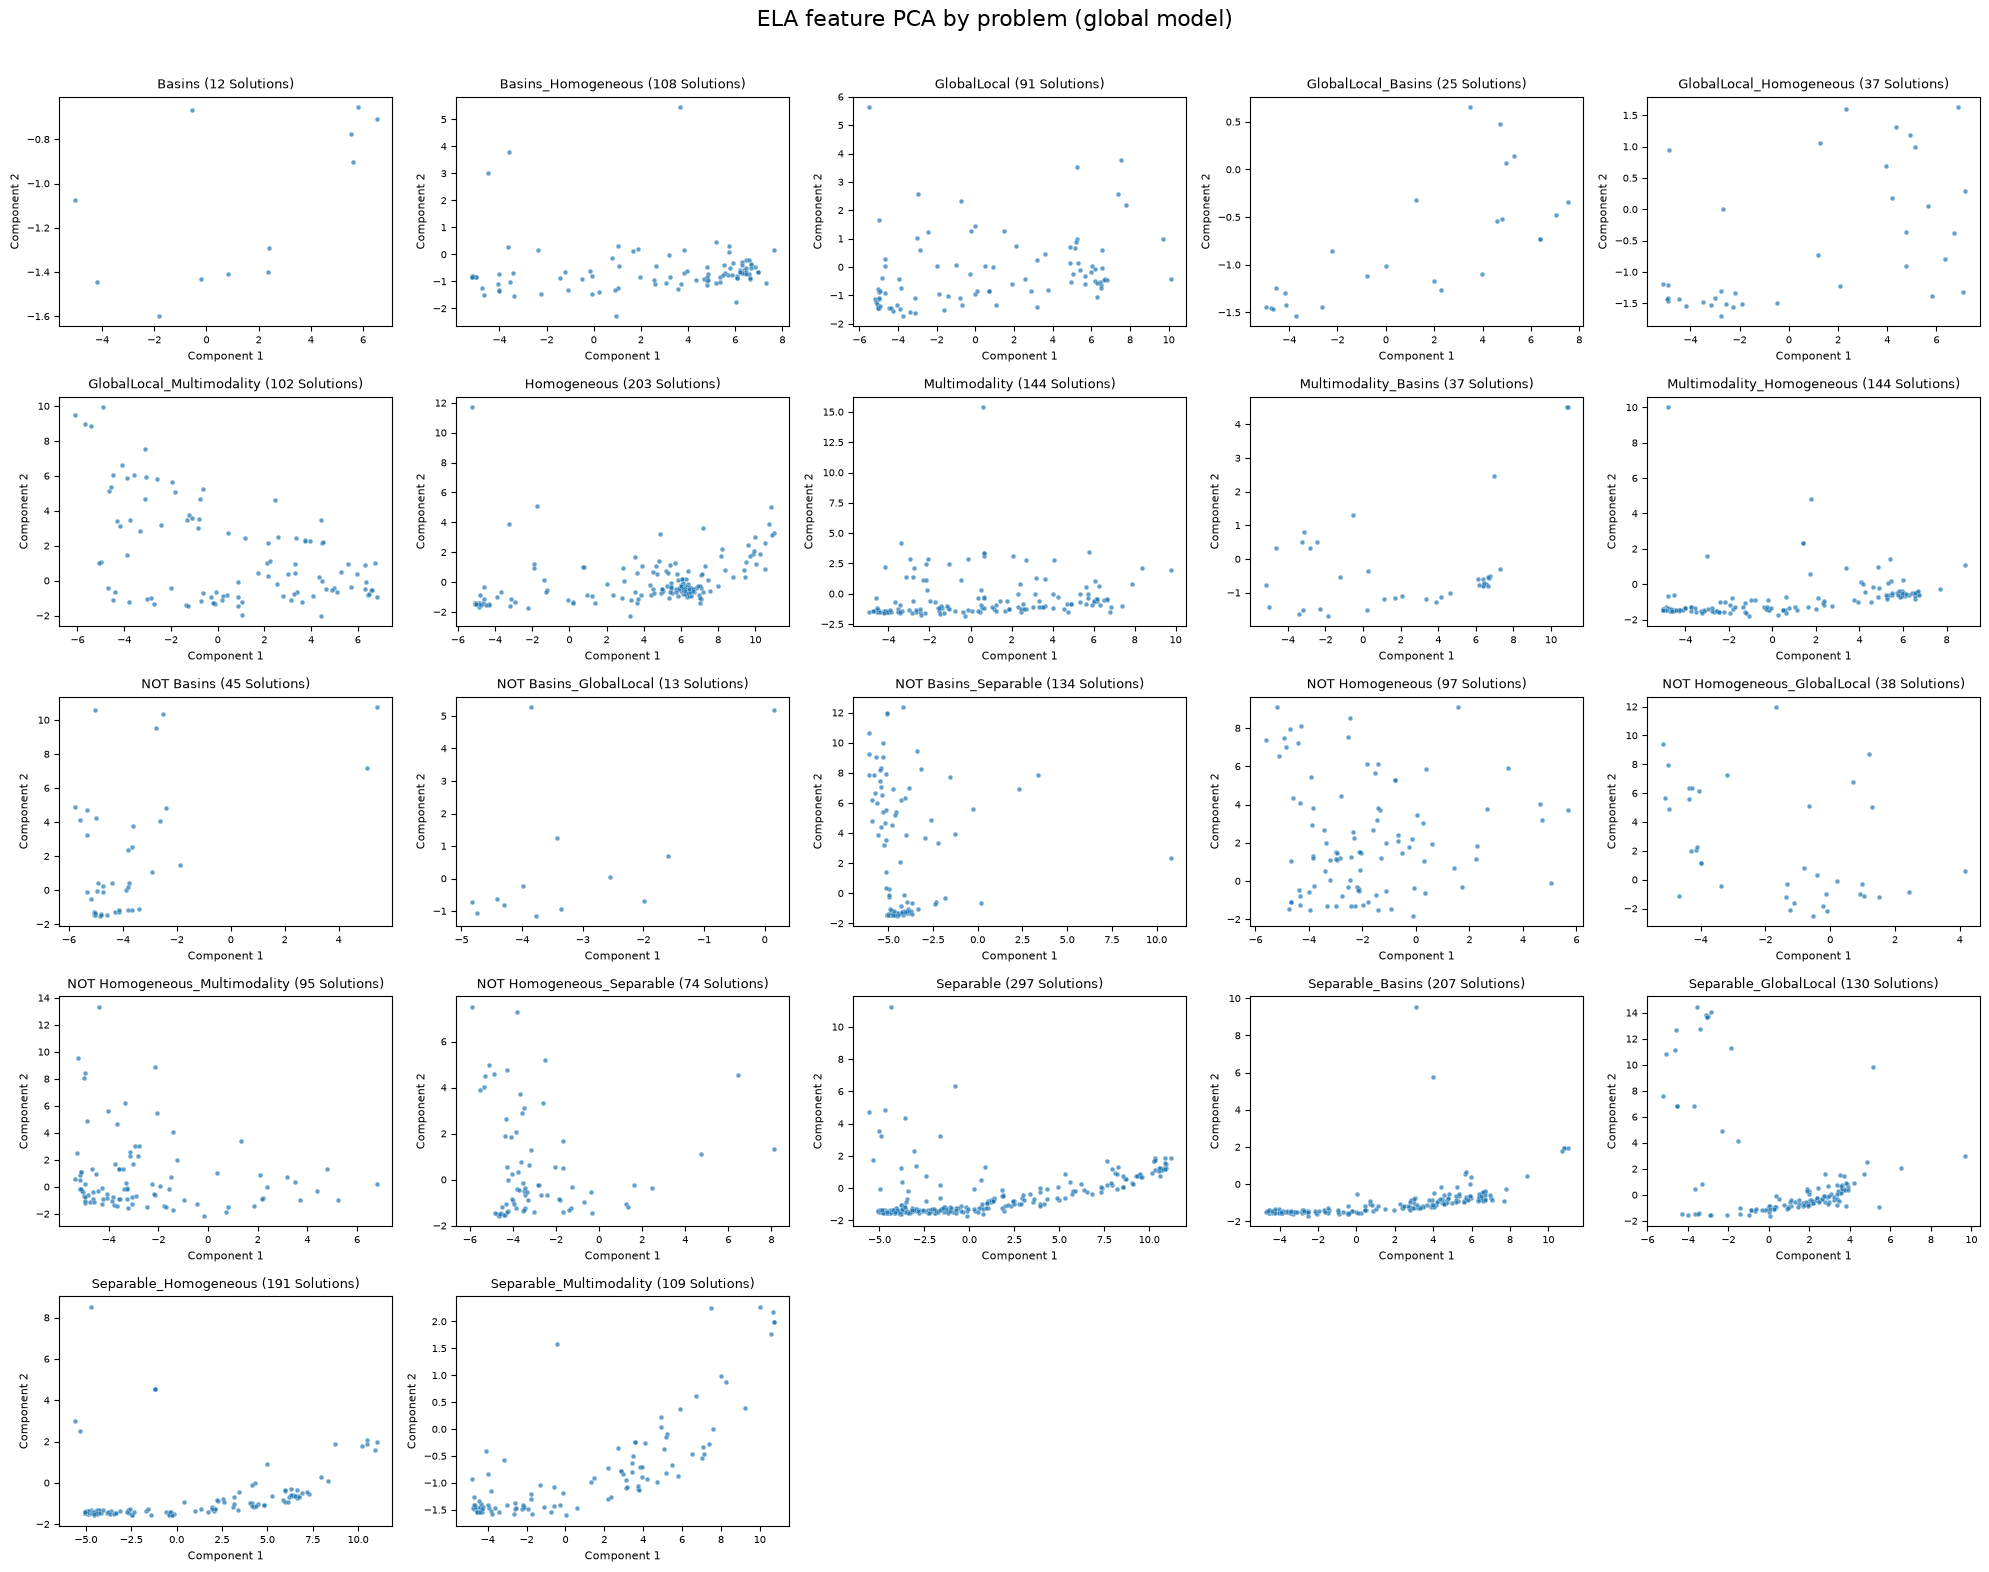

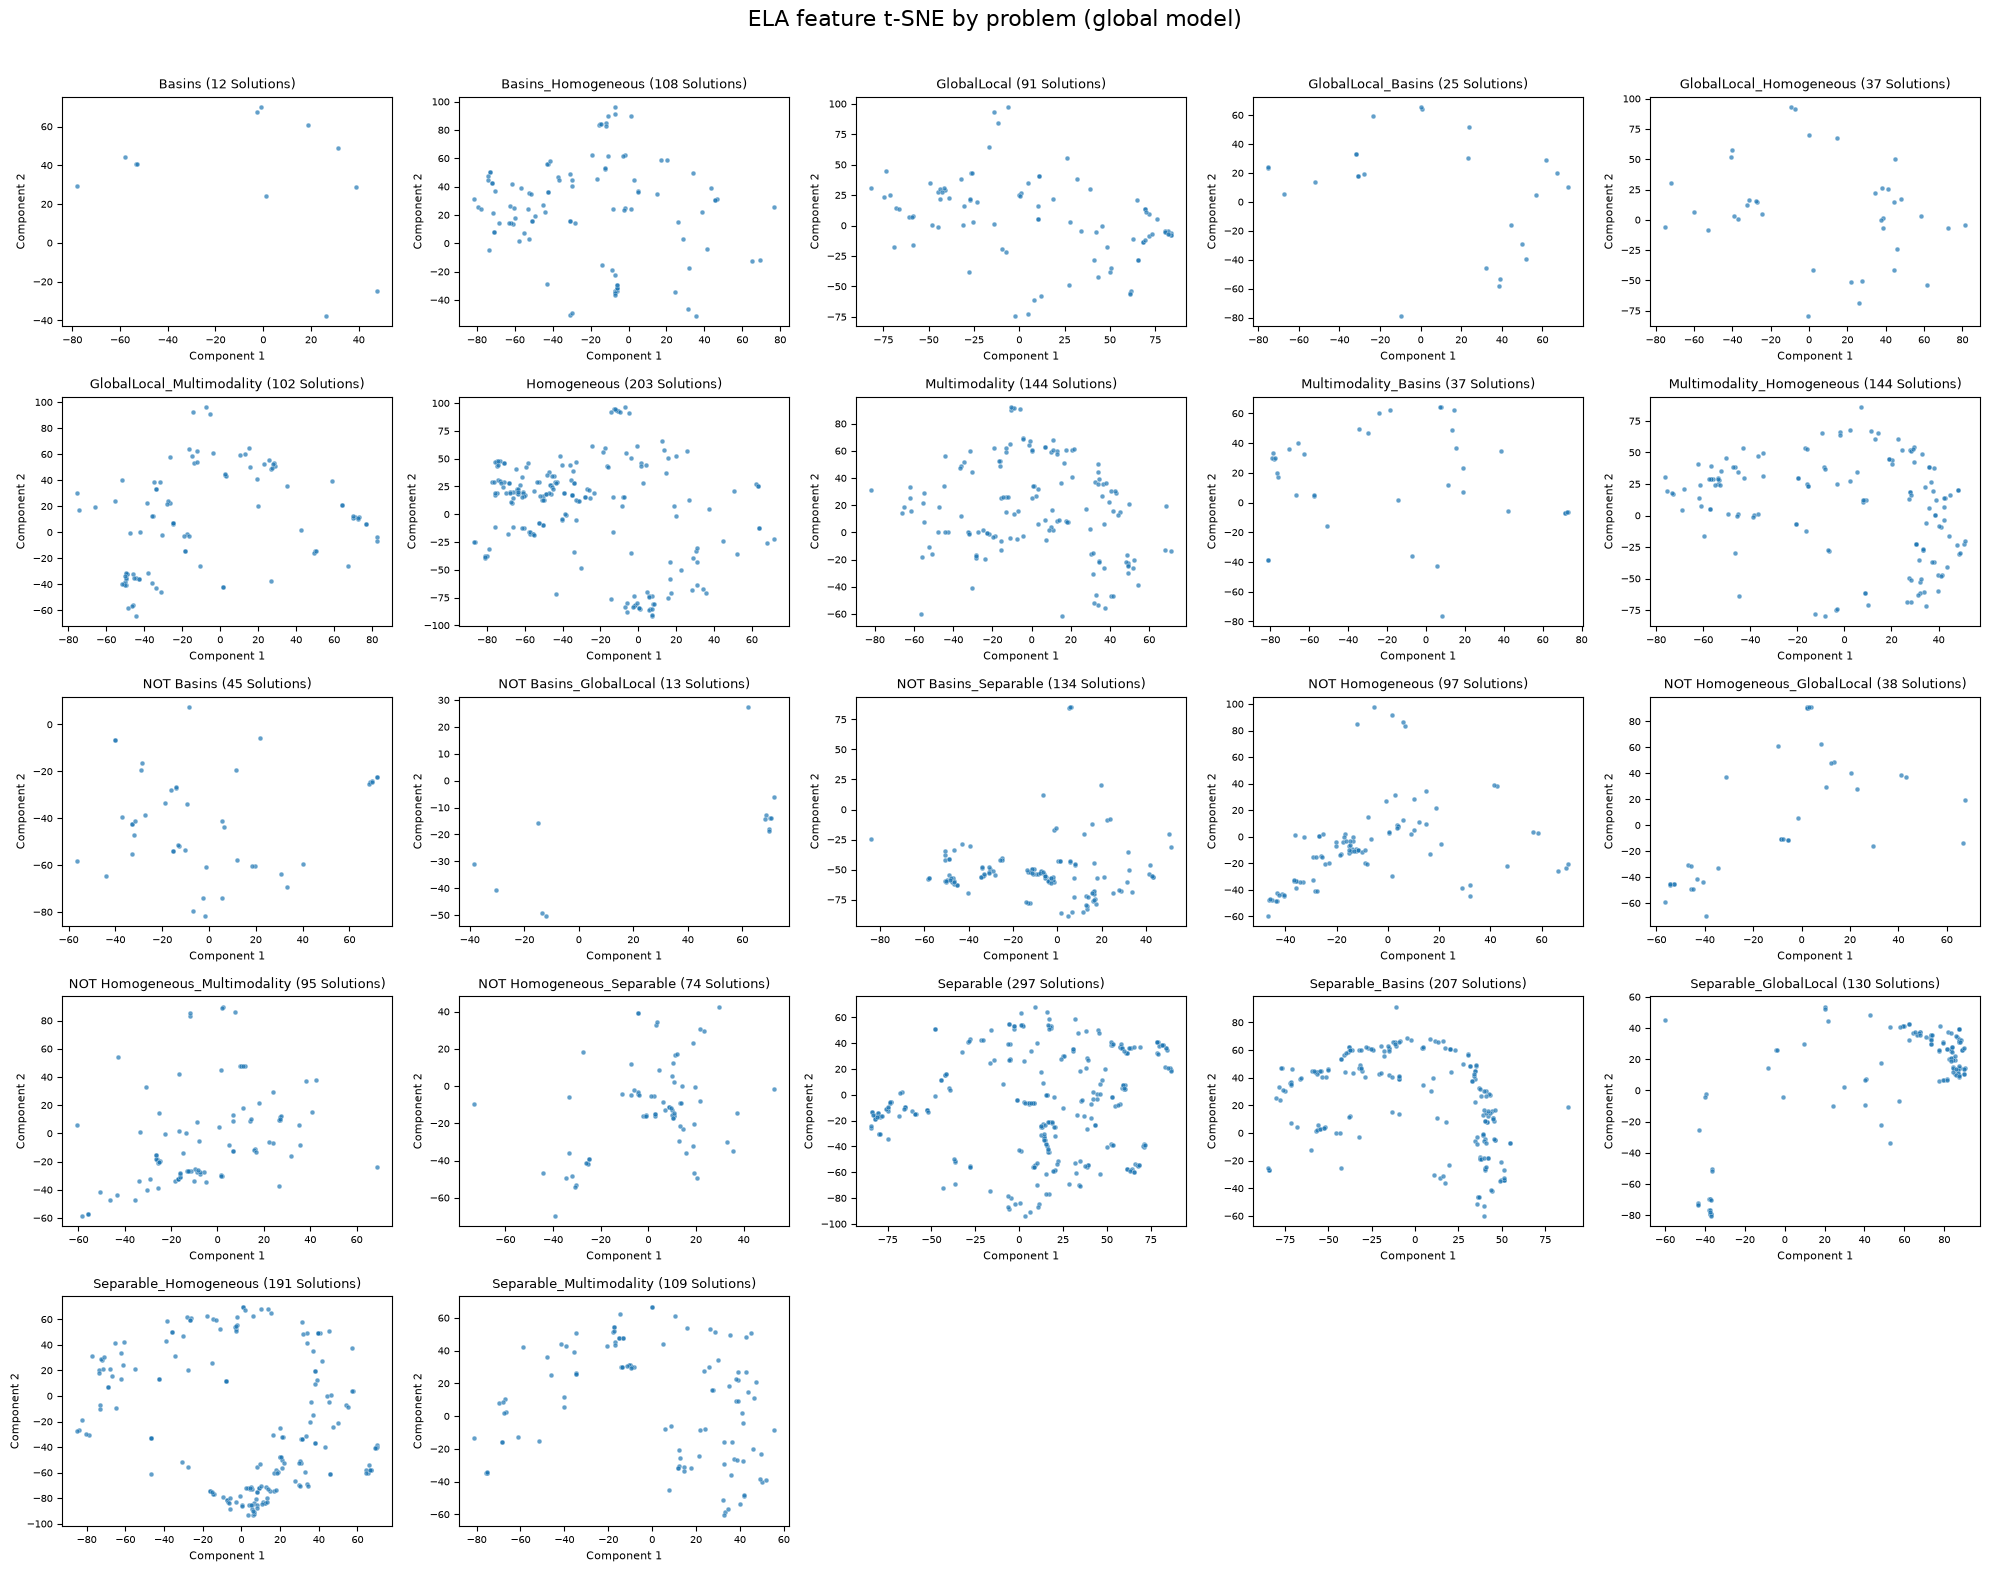

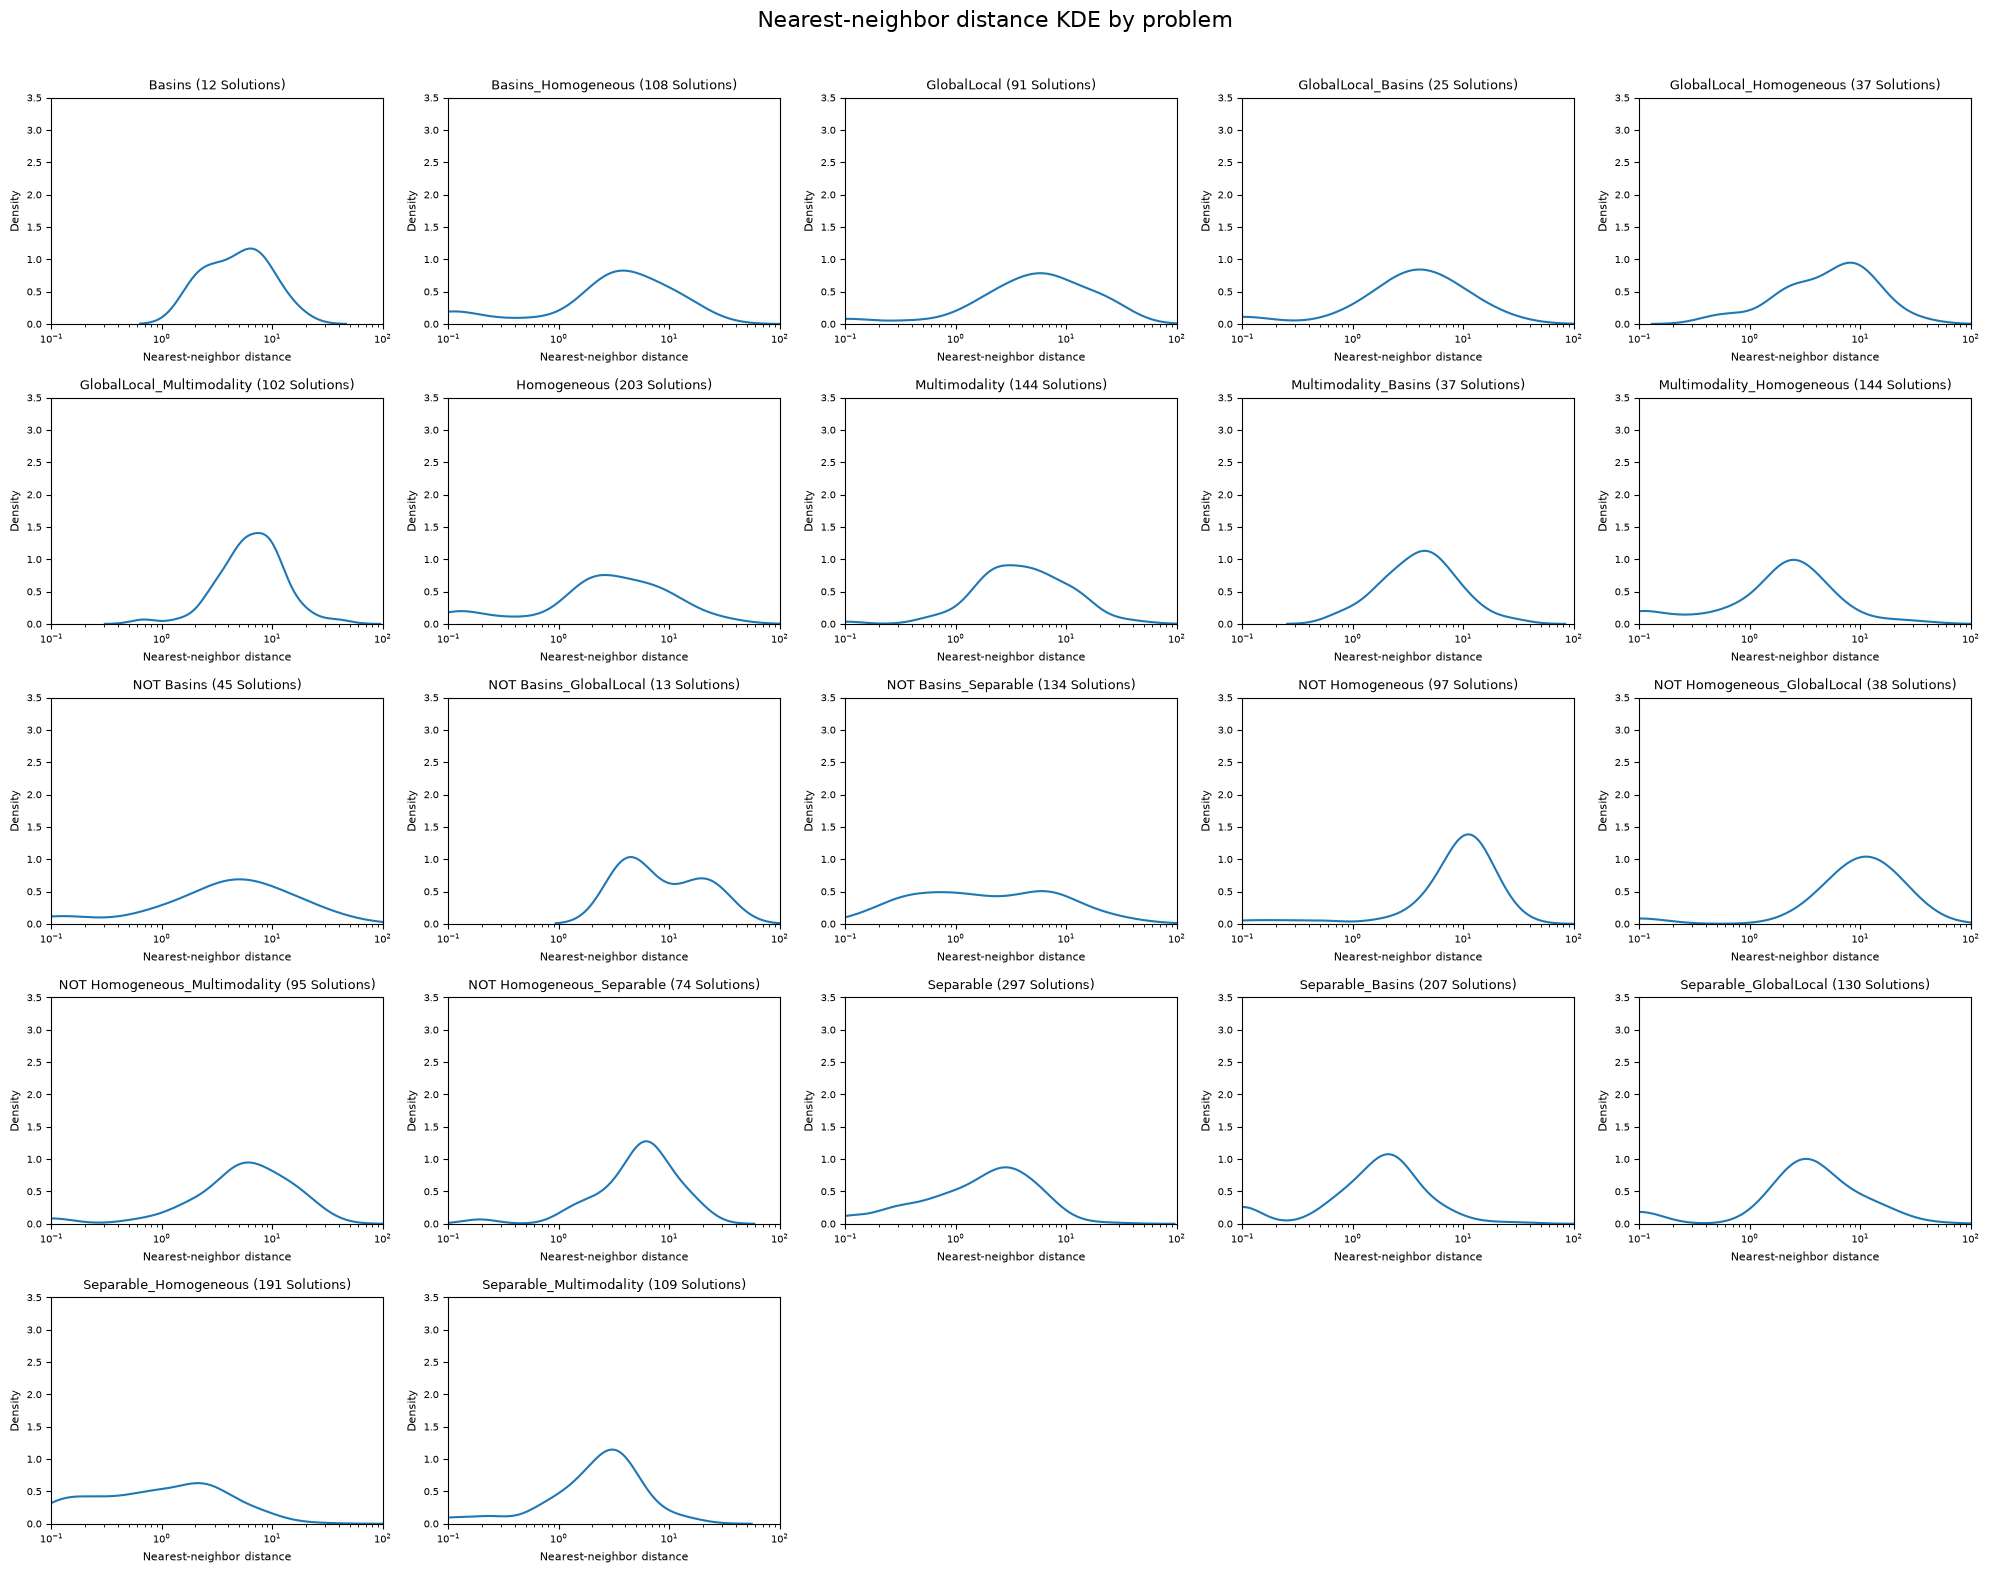

,Problem,Solutions,"KDE Weighted Mean [0,100]"
0,Basins,12,5.8173
1,Basins_Homogeneous,108,5.2737
2,GlobalLocal,91,8.6722
3,GlobalLocal_Basins,25,5.2751
4,GlobalLocal_Homogeneous,37,7.5175
5,GlobalLocal_Multimodality,102,8.0246
6,Homogeneous,203,5.3186
7,Multimodality,144,6.2667
8,Multimodality_Basins,37,5.4691
9,Multimodality_Homogeneous,144,3.4496


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
import joblib

def _plot_on_ax(row, ax, bounds=(-5, 5), res=300):
        ns = {}
        exec(row["code"], ns)
        f = getattr(ns[row["name"]](dim=2), "f")

        x = np.linspace(*bounds, res)
        y = np.linspace(*bounds, res)
        X, Y = np.meshgrid(x, y)
        Z = np.apply_along_axis(f, 1, np.stack([X.ravel(), Y.ravel()], axis=1)).reshape(X.shape)

        cs = ax.contour(X, Y, Z, levels=40, linewidths=0.6)
        #ax.clabel(cs, cs.levels[::2], inline=True, fontsize=6, fmt="%.2g")  # optional labels

        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"{row['name']}", fontsize=7)
        for spine in ax.spines.values():
            spine.set_edgecolor("black")
            spine.set_linewidth(1.0)

def min_nearest_neighbor_distances(df, num_cols):
    """
    For each row, compute the distance to its nearest neighbor.
    Returns a Series aligned to df.index with NaN if there are fewer than 2 rows.
    """
    X = df[num_cols].astype(float).copy()
    out = pd.Series(np.nan, index=df.index, name="min_nearest_neighbor_dist")

    Xi = X.to_numpy()
    if len(Xi) < 2:
        return out

    dists = pairwise_distances(Xi, metric='cityblock')
    np.fill_diagonal(dists, np.inf)
    mins = dists.min(axis=1)
    out.loc[df.index] = np.where(mins < 0.1, 0.1, mins)

    return out


# Train a standard scaler
if True:
    all_ela_data = []

    for problem in problems:
        data = logger.get_problem_data(problem_name=problem)
        meta_df = pd.json_normalize(data['metadata'])

        expected_len = meta_df["ela_features"].apply(lambda v: len(v) if hasattr(v, '__len__') else 0).mode()[0]
        meta_df = meta_df[meta_df["ela_features"].apply(
            lambda v: hasattr(v, '__len__') and len(v) == expected_len
        )]
        meta_df["ela_features"] = meta_df["ela_features"].apply(
            lambda v: v[0] if isinstance(v, (list, tuple)) and len(v) == 1 else v
        )
        #remove nans and infs
        meta_df = meta_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["ela_features"])

        try:
            ela_mat = np.vstack(meta_df["ela_features"].values)
            all_ela_data.append(ela_mat)
        except Exception as e:
            print(f"Error processing problem {problem}: {e}")
            continue
    # combine into one big matrix
    all_ela_data = np.vstack(all_ela_data)

    # remove inf and NaN
    all_ela_data = np.where(np.isfinite(all_ela_data), all_ela_data, np.nan)
    mask = ~np.isnan(all_ela_data).any(axis=1)
    all_ela_data = all_ela_data[mask]

    # fit one scaler
    scaler = StandardScaler().fit(all_ela_data)
    joblib.dump(scaler, "ela_scaler.joblib")

embedding_inputs = []
distance_plots = []
kde_mean_results = []

for problem in problems:
    data = logger.get_problem_data(problem_name=problem)

    # Get feature names from problem name
    feature_names = problem.split("_")[0:2]  # e.g. "basins_separable" -> ["basins", "separable"] and "basins" --> ["basins"]

    try:
        # Filter the best fitness values above 0.75 threshold
        #print(data["fitness"].describe())
        meta_df = pd.json_normalize(data['metadata'])

        if len(feature_names) == 1:
            index_mask = meta_df['score_' + feature_names[0] + '_2D'] > 0.499999
        elif len(feature_names) == 2:
            index_mask = (meta_df['score_' + feature_names[0] + '_2D'] > 0.499999) & (meta_df['score_' + feature_names[1] + '_2D'] > 0.499999)
        else:
            raise ValueError(f"Unexpected number of features in problem name: {problem}")

        df_best = data.loc[index_mask].copy()
        meta_df = meta_df.loc[index_mask].copy()

        #print(meta_df.columns)

        expected_len = meta_df["ela_features"].apply(lambda v: len(v) if hasattr(v, '__len__') else 0).mode()[0]
        meta_df = meta_df[meta_df["ela_features"].apply(
            lambda v: hasattr(v, '__len__') and len(v) == expected_len
        )]

        meta_df["ela_features"] = meta_df["ela_features"].apply(lambda v: v[0] if isinstance(v, (list, tuple)) and len(v)==1 else v)

        # -- explode into separate numeric columns
        ela_mat = np.vstack(meta_df["ela_features"].values)
        ela_cols = [f"ela_{i}" for i in range(ela_mat.shape[1])]
        ela_df   = pd.DataFrame(ela_mat, columns=ela_cols, index=meta_df.index)

        df = pd.concat([df_best, ela_df], axis=1)
        #remove inf values from ela_cols dataframe
        df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=ela_cols)

        if len(df) < 6:
            print(f"Skipped problem {problem}: only {len(df)} solutions")
            continue

        #print(df.columns)
        scaler = joblib.load(f"ela_scaler.joblib")
        
        X_scaled = scaler.transform(df[ela_cols].to_numpy())
        embedding_inputs.append((problem, X_scaled))

        # Now get a numerical diversity metric on the ELA features
        df[ela_cols] = X_scaled
        min_d = min_nearest_neighbor_distances(df, ela_cols)
        distance_plots.append((problem, min_d.copy()))
        #print(min_d.head())
        #print(min_d.describe())
        
        from scipy.stats import gaussian_kde
        from scipy.integrate import quad
        vals = min_d.dropna().to_numpy()
        weighted_mean = np.nan
        if len(vals) > 1 and len(np.unique(vals)) > 1:
            kde = gaussian_kde(vals)
            # weighted_mean = quad(lambda x: x * kde(x), 0, 100)[0]

            weighted_mean = quad(lambda x: float(x * kde(x)[0]), 0, 100)[0]

        kde_mean_results.append((problem, len(df), weighted_mean))

    except Exception as e:
        print(f"Failed on problem {problem}: {e}")


def build_global_embeddings(embedding_inputs, tsne_perplexity=6):
    pca_plots = []
    tsne_plots = []

    if not embedding_inputs:
        print("No ELA feature data available for global embeddings.")
        return pca_plots, tsne_plots

    all_X = np.vstack([X for _, X in embedding_inputs])
    lengths = [len(X) for _, X in embedding_inputs]

    if min(all_X.shape) < 2:
        print("Need at least two samples and two ELA features for 2D global embeddings.")
        return pca_plots, tsne_plots

    pca_model = PCA(n_components=2).fit(all_X)
    all_pca = pca_model.transform(all_X)

    perplexity = min(tsne_perplexity, len(all_X) - 1)
    all_tsne = TSNE(
        n_components=2,
        learning_rate='auto',
        init='random',
        perplexity=perplexity,
        random_state=0
    ).fit_transform(all_X)

    start = 0
    for (problem, _), length in zip(embedding_inputs, lengths):
        end = start + length
        pca_plots.append((problem, all_pca[start:end]))
        tsne_plots.append((problem, all_tsne[start:end]))
        start = end

    return pca_plots, tsne_plots


def plot_embedding_grid(plot_data, title):
    rows, cols = 5, 5
    fig, axes = plt.subplots(rows, cols, figsize=(20, 16))

    for ax, (problem, embedding) in zip(axes.ravel(), plot_data):
        sns.scatterplot(
            x=embedding[:, 0], y=embedding[:, 1],
            ax=ax, s=12, alpha=0.7, legend=False
        )
        n_solutions = len(embedding)
        ax.set_title(f"{problem} ({n_solutions} Solutions)", fontsize=9)
        ax.set_xlabel("Component 1", fontsize=8)
        ax.set_ylabel("Component 2", fontsize=8)
        ax.tick_params(labelsize=7)

    for ax in axes.ravel()[len(plot_data):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=16)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()


def plot_distance_grid(plot_data, title, kind="hist"):
    rows, cols = 5, 5
    fig, axes = plt.subplots(rows, cols, figsize=(20, 16))

    for ax, (problem, distances) in zip(axes.ravel(), plot_data):
        values = distances.dropna().to_numpy()
        plotted = len(values) > 0
        if kind == "hist" and plotted:
            sns.histplot(values, bins=100, log_scale=True, alpha=0.3,
                         kde=True, stat="density", ax=ax)
        elif len(values) > 1 and len(np.unique(values)) > 1:
            sns.kdeplot(values, log_scale=True, ax=ax)
        else:
            plotted = False

        n_solutions = len(values)
        ax.set_title(f"{problem} ({n_solutions} Solutions)", fontsize=9)
        ax.set_xlabel("Nearest-neighbor distance", fontsize=8)
        ax.set_ylabel("Density", fontsize=8)
        ax.set_xlim(0.1, 100)
        ax.set_ylim(0, 3.5)
        ax.tick_params(labelsize=7)
        if not plotted:
            ax.text(0.5, 0.5, "No matching data", ha="center", va="center",
                    transform=ax.transAxes, fontsize=8)

    for ax in axes.ravel()[len(plot_data):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=16)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()


pca_plots, tsne_plots = build_global_embeddings(embedding_inputs)
plot_embedding_grid(pca_plots, "ELA feature PCA by problem (global model)")
plot_embedding_grid(tsne_plots, "ELA feature t-SNE by problem (global model)")
plot_distance_grid(distance_plots, "Nearest-neighbor distance KDE by problem", kind="kde")

df_kde = pd.DataFrame(kde_mean_results, columns=["Problem", "Solutions", "KDE Weighted Mean [0,100]"])
df_kde = df_kde[df_kde["Solutions"] >= 10]
df_kde = df_kde.dropna(subset=["KDE Weighted Mean [0,100]"])
# df_kde = df_kde.sort_values("KDE Weighted Mean [0,100]", ascending=False)

from IPython.display import display
display(df_kde.style.format({"KDE Weighted Mean [0,100]": "{:.4f}"}))

PCA explained variance ratio: PC1=0.5317, PC2=0.1502, total=0.6819


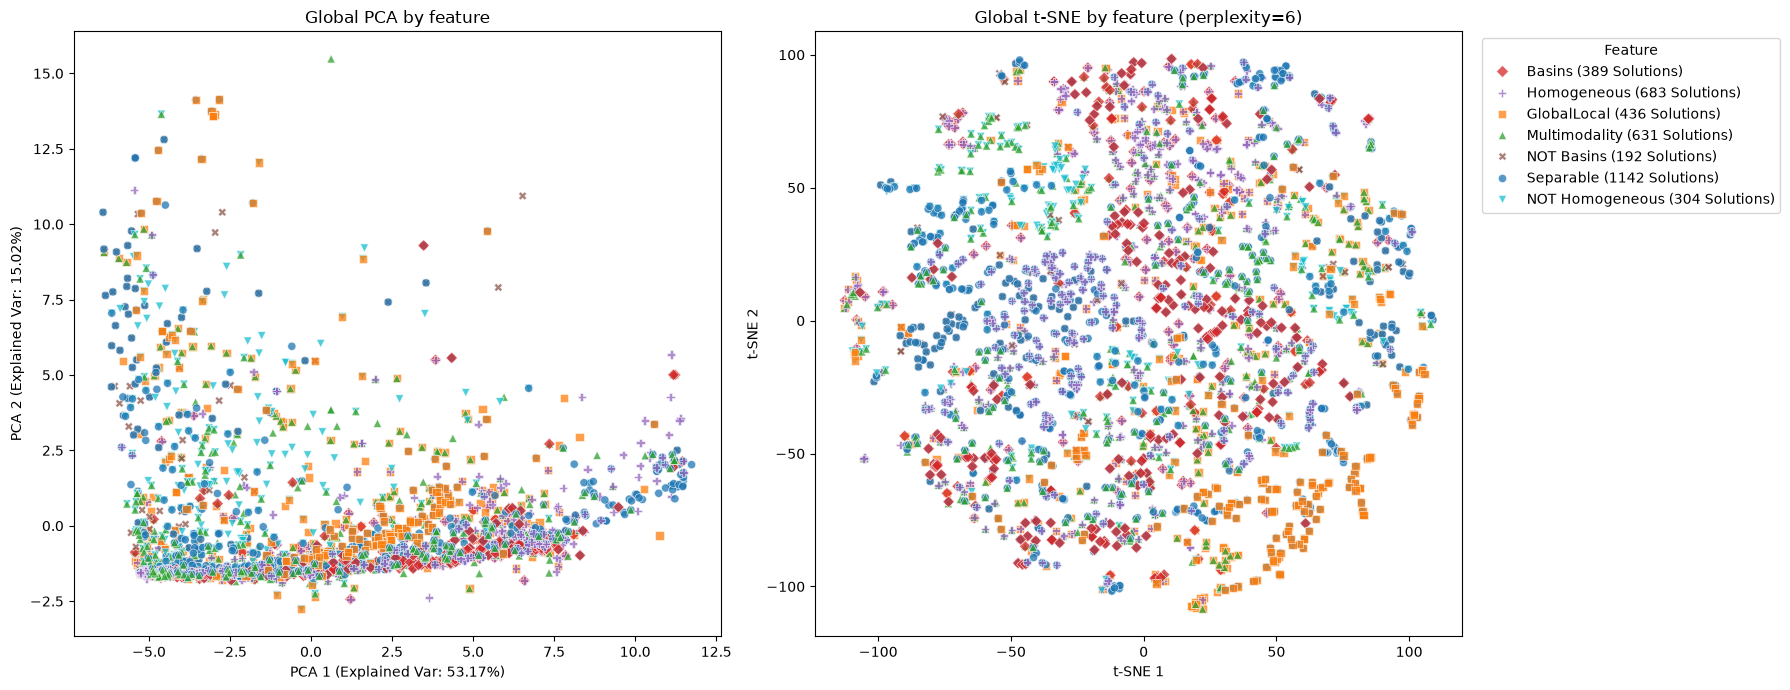

In [5]:
target_features = [
    "Separable",
    "GlobalLocal",
    "Multimodality",
    "Basins",
    "Homogeneous",
    "NOT Basins",
    "NOT Homogeneous",
]

feature_styles = {
    "Separable": {"color": "#1f77b4", "marker": "o"},
    "GlobalLocal": {"color": "#ff7f0e", "marker": "s"},
    "Multimodality": {"color": "#2ca02c", "marker": "^"},
    "Basins": {"color": "#d62728", "marker": "D"},
    "Homogeneous": {"color": "#9467bd", "marker": "P"},
    "NOT Basins": {"color": "#8c564b", "marker": "X"},
    "NOT Homogeneous": {"color": "#17becf", "marker": "v"},
}

min_solutions_per_feature = 10
tsne_perplexity = 6


def _extract_problem_ela(problem):
    data = logger.get_problem_data(problem_name=problem)
    meta_df = pd.json_normalize(data["metadata"])
    problem_features = problem.split("_")

    score_cols = [f"score_{feature}_2D" for feature in problem_features]
    missing_cols = [col for col in score_cols if col not in meta_df.columns]
    if missing_cols:
        print(f"Skipped problem {problem}: missing score columns {missing_cols}")
        return None, None

    index_mask = np.logical_and.reduce([meta_df[col] > 0.499999 for col in score_cols])
    df_best = data.loc[index_mask].copy()
    meta_df = meta_df.loc[index_mask].copy()

    if meta_df.empty:
        return None, None

    expected_len = meta_df["ela_features"].apply(lambda v: len(v) if hasattr(v, "__len__") else 0).mode()[0]
    meta_df = meta_df[meta_df["ela_features"].apply(
        lambda v: hasattr(v, "__len__") and len(v) == expected_len
    )]
    meta_df["ela_features"] = meta_df["ela_features"].apply(
        lambda v: v[0] if isinstance(v, (list, tuple)) and len(v) == 1 else v
    )

    if meta_df.empty:
        return None, None

    ela_mat = np.vstack(meta_df["ela_features"].values)
    ela_cols = [f"ela_{i}" for i in range(ela_mat.shape[1])]
    ela_df = pd.DataFrame(ela_mat, columns=ela_cols, index=meta_df.index)
    df = pd.concat([df_best, ela_df], axis=1)
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=ela_cols)

    if df.empty:
        return None, None

    return df[ela_cols].to_numpy(), problem_features


feature_rows = []
for problem in problems:
    try:
        ela_mat, problem_features = _extract_problem_ela(problem)
        if ela_mat is None:
            continue

        for feature in problem_features:
            if feature not in target_features:
                continue
            for row in ela_mat:
                feature_rows.append({"Problem": problem, "Feature": feature, "ELA": row})
    except Exception as e:
        print(f"Failed on problem {problem}: {e}")


feature_df = pd.DataFrame(feature_rows)
feature_counts = feature_df["Feature"].value_counts() if not feature_df.empty else pd.Series(dtype=int)
selected_features = [
    feature for feature in target_features
    if feature_counts.get(feature, 0) >= min_solutions_per_feature
]

skipped_features = [
    feature for feature in target_features
    if feature_counts.get(feature, 0) < min_solutions_per_feature
]
for feature in skipped_features:
    print(f"Skipped feature {feature}: only {feature_counts.get(feature, 0)} solutions")

feature_df = feature_df[feature_df["Feature"].isin(selected_features)].copy()

if feature_df.empty:
    print("No feature groups have enough solutions to plot.")
else:
    X = np.vstack(feature_df["ELA"].values)
    X_scaled = StandardScaler().fit_transform(X)

    pca_model = PCA(n_components=2)
    feature_df["PCA 1"], feature_df["PCA 2"] = pca_model.fit_transform(X_scaled).T

    print(
        f"PCA explained variance ratio: PC1={pca_model.explained_variance_ratio_[0]:.4f}, "
        f"PC2={pca_model.explained_variance_ratio_[1]:.4f}, "
        f"total={pca_model.explained_variance_ratio_.sum():.4f}"
    )

    perplexity = min(tsne_perplexity, len(feature_df) - 1)
    tsne_embedding = TSNE(
        n_components=2,
        learning_rate="auto",
        init="random",
        perplexity=perplexity,
        random_state=0,
    ).fit_transform(X_scaled)
    feature_df["t-SNE 1"], feature_df["t-SNE 2"] = tsne_embedding.T

    labels = {
        feature: f"{feature} ({feature_counts[feature]} Solutions)"
        for feature in selected_features
    }
    plot_df = feature_df.assign(FeatureLabel=feature_df["Feature"].map(labels))
    label_palette = {
        labels[feature]: feature_styles[feature]["color"]
        for feature in selected_features
    }
    label_markers = {
        labels[feature]: feature_styles[feature]["marker"]
        for feature in selected_features
    }

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    sns.scatterplot(
        data=plot_df,
        x="PCA 1",
        y="PCA 2",
        hue="FeatureLabel",
        style="FeatureLabel",
        palette=label_palette,
        markers=label_markers,
        s=35,
        alpha=0.75,
        ax=axes[0],
    )
    axes[0].set_title("Global PCA by feature")
    axes[0].set_xlabel(f"PCA 1 (Explained Var: {pca_model.explained_variance_ratio_[0]:.2%})")
    axes[0].set_ylabel(f"PCA 2 (Explained Var: {pca_model.explained_variance_ratio_[1]:.2%})")

    sns.scatterplot(
        data=plot_df,
        x="t-SNE 1",
        y="t-SNE 2",
        hue="FeatureLabel",
        style="FeatureLabel",
        palette=label_palette,
        markers=label_markers,
        s=35,
        alpha=0.75,
        ax=axes[1],
    )
    axes[1].set_title(f"Global t-SNE by feature (perplexity={perplexity})")

    axes[0].legend_.remove()
    axes[1].legend(title="Feature", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()


Loaded cached BBOB ELA features from /local/bodasap/BLADE/examples/bbob_classical_ela_5d.pkl
PCA explained variance ratio: PC1=0.5090, PC2=0.1530, total=0.6620


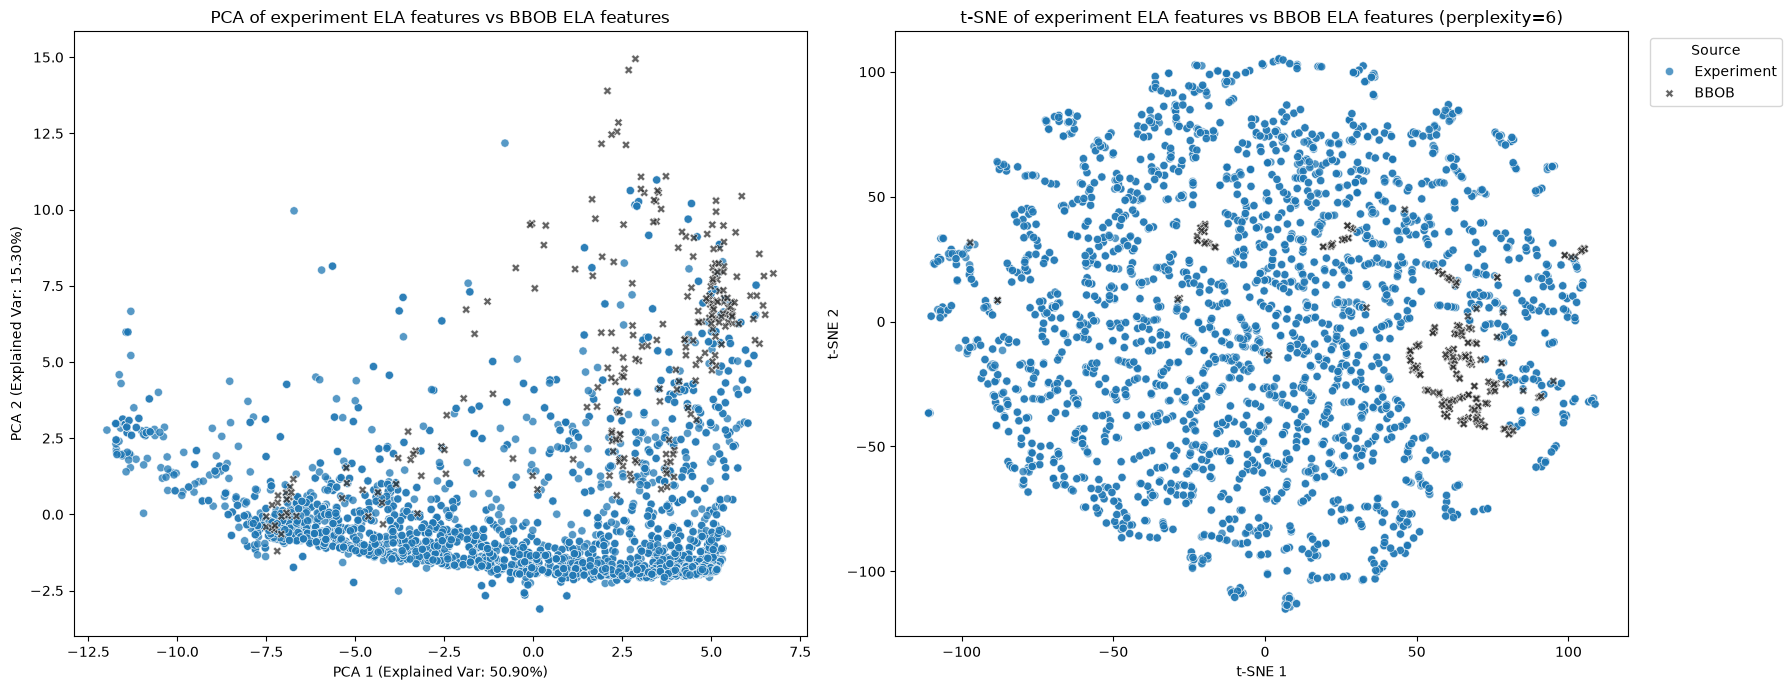

In [6]:
import sys
from pathlib import Path
import ioh

sys.path.append("/local/bodasap/LLaMEA/pflacco")

from pflacco.classical_ela_features import *

def preprocess_ela_features(feature_df):
    feature_df = feature_df.copy()
    feature_df = feature_df.dropna(axis=1, how="any")
    return feature_df[feature_df.columns.drop(list(feature_df.filter(regex="costs_runtime")))]

def safe_scale_xy(X, y):
    X = pd.DataFrame(X).astype(float).copy()
    y = pd.Series(y).astype(float).copy()

    X_range = (X.max() - X.min()).replace(0, 1.0)
    X_scaled = (X - X.min()) / X_range

    y_min = float(y.min())
    y_max = float(y.max())
    if np.isclose(y_max, y_min):
        y_scaled = pd.Series(np.zeros(len(y)), index=y.index)
    else:
        y_scaled = (y - y_min) / (y_max - y_min)

    return X_scaled, y_scaled

def compute_classical_ela(X, y):
    """Compute the same classical pflacco ELA feature vector used in the experiments."""
    X_scaled, y_scaled = safe_scale_xy(X, y)
    features = {
        **calculate_ela_meta(X_scaled, y_scaled),
        **calculate_ela_distribution(X_scaled, y_scaled),
        **calculate_nbc(X_scaled, y_scaled),
        **calculate_dispersion(X_scaled, y_scaled),
        **calculate_pca(X_scaled, y_scaled),
        **calculate_information_content(X_scaled, y_scaled),
    }
    return preprocess_ela_features(pd.DataFrame([features])).iloc[0]

if "feature_df" not in globals() or feature_df.empty:
    print("No existing feature_df found from the earlier cells, so there is nothing to compare.")
else:
    def build_bbob_ela_rows(dim=5, n=250, seed=42, instance_ids=range(1, 11), cache_path=None):
        if cache_path is not None and cache_path.exists():
            cached_df = pd.read_pickle(cache_path)
            rows = cached_df.to_dict("records")
            completed = set(zip(cached_df["Function"], cached_df["Instance"]))
            print(f"Resuming BBOB ELA cache from {cache_path}: {len(rows)} rows")
        else:
            rows = []
            completed = set()

        for fid in range(1, 25):
            for instance_id in instance_ids:
                if (fid, instance_id) in completed:
                    continue

                problem = ioh.get_problem(
                    fid,
                    instance=instance_id,
                    dimension=dim,
                    problem_class=ioh.ProblemClass.BBOB,
                )
                seed_rows = []
                for sample_seed in range(5):
                    rng = np.random.default_rng(seed + fid * 1000 + instance_id * 10 + sample_seed)
                    samples = rng.uniform(-5, 5, size=(n * dim, dim))
                    X = pd.DataFrame(samples, columns=[f"x{i}" for i in range(dim)])
                    y = pd.Series(X.apply(lambda row: problem(row.to_numpy()), axis=1)).copy()
                    y[y == 0] = 0.1 ** 100
                    seed_rows.append(compute_classical_ela(X, y))

                feature_row = pd.concat(seed_rows, axis=1).T.mean()
                rows.append(
                    {
                        "Source": "BBOB",
                        "Problem": f"BBOB f{fid}",
                        "Function": fid,
                        "Instance": instance_id,
                        "ELA": feature_row.to_numpy(),
                    }
                )

                if cache_path is not None:
                    pd.DataFrame(rows).to_pickle(cache_path)
                    print(f"Cached {len(rows)} BBOB ELA rows to {cache_path}")

        return pd.DataFrame(rows)

    experiment_df = feature_df.copy()
    experiment_df = experiment_df.assign(Source="Experiment")
    if "Problem" not in experiment_df.columns:
        experiment_df["Problem"] = experiment_df["Feature"].astype(str)

    bbob_cache_path = Path("/local/bodasap/BLADE/examples/bbob_classical_ela_5d.pkl")
    if bbob_cache_path.exists():
        bbob_feature_df = pd.read_pickle(bbob_cache_path)
        print(f"Loaded cached BBOB ELA features from {bbob_cache_path}")
    else:
        bbob_feature_df = build_bbob_ela_rows(
            dim=5,
            n=250,
            seed=42,
            instance_ids=range(1, 11),
            cache_path=bbob_cache_path,
        )

    compare_df = pd.concat(
        [
            experiment_df[["Source", "Problem", "ELA"]],
            bbob_feature_df[["Source", "Problem", "ELA"]],
        ],
        ignore_index=True,
    )

    ela_lengths = compare_df["ELA"].apply(len)
    expected_ela_len = int(feature_df["ELA"].apply(len).mode().iloc[0])
    if not ela_lengths.eq(expected_ela_len).all():
        bad_counts = ela_lengths.value_counts().sort_index().to_dict()
        raise ValueError(f"ELA feature length mismatch before stacking: expected {expected_ela_len}, got counts {bad_counts}")

    X = np.vstack(compare_df["ELA"].values)
    X_scaled = StandardScaler().fit_transform(X)


    pca_model = PCA(n_components=2)
    compare_df[["PCA 1", "PCA 2"]] = pca_model.fit_transform(X_scaled)
    print(
        f"PCA explained variance ratio: PC1={pca_model.explained_variance_ratio_[0]:.4f}, "
        f"PC2={pca_model.explained_variance_ratio_[1]:.4f}, "
        f"total={pca_model.explained_variance_ratio_.sum():.4f}"
    )
    perplexity = min(tsne_perplexity, len(compare_df) - 1)
    tsne_embedding = TSNE(
        n_components=2,
        learning_rate="auto",
        init="random",
        perplexity=perplexity,
        random_state=0,
    ).fit_transform(X_scaled)
    compare_df[["t-SNE 1", "t-SNE 2"]] = tsne_embedding

    source_palette = {
        "Experiment": "#1f77b4",
        "BBOB": "#2f2f2f",
    }
    source_markers = {
        "Experiment": "o",
        "BBOB": "X",
    }

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    sns.scatterplot(
        data=compare_df,
        x="PCA 1",
        y="PCA 2",
        hue="Source",
        style="Source",
        palette=source_palette,
        markers=source_markers,
        s=35,
        alpha=0.75,
        ax=axes[0],
    )
    axes[0].set_title("PCA of experiment ELA features vs BBOB ELA features")
    axes[0].set_xlabel(f"PCA 1 (Explained Var: {pca_model.explained_variance_ratio_[0]:.2%})")
    axes[0].set_ylabel(f"PCA 2 (Explained Var: {pca_model.explained_variance_ratio_[1]:.2%})")

    sns.scatterplot(
        data=compare_df,
        x="t-SNE 1",
        y="t-SNE 2",
        hue="Source",
        style="Source",
        palette=source_palette,
        markers=source_markers,
        s=35,
        alpha=0.75,
        ax=axes[1],
    )
    axes[1].set_title(f"t-SNE of experiment ELA features vs BBOB ELA features (perplexity={perplexity})")
    axes[1].legend(title="Source", bbox_to_anchor=(1.02, 1), loc="upper left")

    if axes[0].legend_ is not None:
        axes[0].legend_.remove()

    plt.tight_layout()
    plt.show()


Filling missing generated rows from overall pool for: ['NOT Basins_Multimodality']


,BBOB mean distance,Generated mean distance,Generated distance variance,Generated distance std
0,11.6697,7.7000,0.3284,0.5731


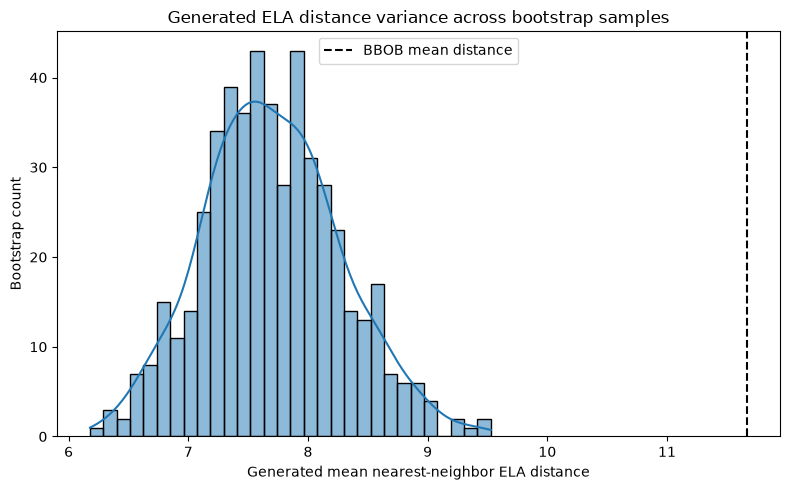

In [7]:
# Compare BBOB internal ELA distances against bootstrapped generated internal ELA distances.
# BBOB: 24 functions x 5 instances = 120 rows.
# Generated: 5 rows from each feature-combination experiment in problems, plus 5 rows from all generated rows.

from IPython.display import display
from pathlib import Path


n_bootstrap = 500
bootstrap_seed = 123
n_bbob_functions = 24
n_instances_per_bbob_function = 5
n_generated_per_problem = 5
n_extra_generated_from_all = 5


def min_intragroup_distances(df, group_col, num_cols):
    """
    For each row, compute the distance to its nearest neighbor within the same group.
    Matches the cityblock nearest-neighbor distance convention used in visualize_ELA.ipynb.
    """
    X = df[num_cols].astype(float).copy()
    out = pd.Series(np.nan, index=df.index, name="min_intragroup_dist")

    for _, group in df.groupby(group_col, sort=False):
        Xi = X.loc[group.index].to_numpy()
        if len(Xi) < 2:
            continue
        dists = pairwise_distances(Xi, metric="cityblock")
        np.fill_diagonal(dists, np.inf)
        mins = dists.min(axis=1)
        out.loc[group.index] = np.where(mins < 0.1, 0.1, mins)

    return out


def _load_or_build_bbob_features():
    bbob_cache_path = Path("/local/bodasap/BLADE/examples/bbob_classical_ela_5d.pkl")
    if bbob_cache_path.exists():
        return pd.read_pickle(bbob_cache_path)
    if "build_bbob_ela_rows" not in globals():
        raise RuntimeError("Run the previous BBOB ELA cell once, or define build_bbob_ela_rows, before this comparison.")
    return build_bbob_ela_rows(
        dim=5,
        n=250,
        seed=42,
        instance_ids=range(1, 11),
        cache_path=bbob_cache_path,
    )


def _select_bbob_function_instances(bbob_feature_df):
    bbob_rows = (
        bbob_feature_df.sort_values(["Function", "Instance"])
        .groupby("Function", sort=True)
        .head(n_instances_per_bbob_function)
        .reset_index(drop=True)
    )
    expected_rows = n_bbob_functions * n_instances_per_bbob_function
    if bbob_rows["Function"].nunique() != n_bbob_functions or len(bbob_rows) != expected_rows:
        raise ValueError(
            f"Expected {expected_rows} BBOB rows from {n_bbob_functions} functions x "
            f"{n_instances_per_bbob_function} instances, got {len(bbob_rows)} rows and "
            f"{bbob_rows['Function'].nunique()} functions."
        )
    return bbob_rows


def _build_generated_problem_rows():
    if "_extract_problem_ela" not in globals():
        raise RuntimeError("Run the feature extraction cell first so _extract_problem_ela is defined.")

    rows = []
    missing_problems = []
    for problem in problems:
        ela_mat, _ = _extract_problem_ela(problem)
        if ela_mat is None or len(ela_mat) == 0:
            missing_problems.append(problem)
            continue
        for ela in ela_mat:
            rows.append({"Problem": problem, "ELA": np.asarray(ela, dtype=float)})

    generated_problem_df = pd.DataFrame(rows)
    if generated_problem_df.empty:
        raise ValueError("No generated ELA rows are available from any problem combination.")
    if missing_problems:
        print(f"Filling missing generated rows from overall pool for: {missing_problems}")
    return generated_problem_df


def _ela_key(ela):
    return tuple(np.round(np.asarray(ela, dtype=float), 12))


def _sample_overall_indices(generated_problem_df, selected_keys, rng, size):
    remaining_all = generated_problem_df[~generated_problem_df["ELA_key"].isin(selected_keys)]
    pool = remaining_all if len(remaining_all) > 0 else generated_problem_df
    return rng.choice(pool.index.to_numpy(), size=size, replace=len(pool) < size)


def _sample_generated_rows(generated_problem_df, rng):
    selected_indices = []
    selected_keys = set()

    for problem in problems:
        group = generated_problem_df[generated_problem_df["Problem"] == problem]
        shuffled_idx = rng.permutation(group.index.to_numpy())
        picked = []
        for idx in shuffled_idx:
            key = generated_problem_df.at[idx, "ELA_key"]
            if key in selected_keys:
                continue
            picked.append(idx)
            selected_keys.add(key)
            if len(picked) == n_generated_per_problem:
                break

        if len(picked) < n_generated_per_problem:
            extra = _sample_overall_indices(
                generated_problem_df,
                selected_keys,
                rng,
                n_generated_per_problem - len(picked),
            )
            for idx in extra.tolist():
                picked.append(idx)
                selected_keys.add(generated_problem_df.at[idx, "ELA_key"])

        selected_indices.extend(picked)

    extra_all = _sample_overall_indices(
        generated_problem_df,
        selected_keys,
        rng,
        n_extra_generated_from_all,
    )
    selected_indices.extend(extra_all.tolist())

    return generated_problem_df.loc[selected_indices].copy()


bbob_rows = _select_bbob_function_instances(_load_or_build_bbob_features())
generated_problem_df = _build_generated_problem_rows()
generated_problem_df["ELA_key"] = generated_problem_df["ELA"].apply(_ela_key)

expected_bbob_rows = n_bbob_functions * n_instances_per_bbob_function
expected_generated_rows = len(problems) * n_generated_per_problem + n_extra_generated_from_all
if expected_bbob_rows != expected_generated_rows:
    raise ValueError(
        f"Sample sizes differ: BBOB has {expected_bbob_rows}, generated has {expected_generated_rows}. "
        f"Check len(problems)={len(problems)}."
    )

expected_ela_len = int(generated_problem_df["ELA"].apply(len).mode().iloc[0])
all_lengths = pd.concat([generated_problem_df["ELA"].apply(len), bbob_rows["ELA"].apply(len)])
if not all_lengths.eq(expected_ela_len).all():
    bad_counts = all_lengths.value_counts().sort_index().to_dict()
    raise ValueError(f"ELA feature length mismatch before stacking: expected {expected_ela_len}, got counts {bad_counts}")

scaler = StandardScaler().fit(np.vstack([*generated_problem_df["ELA"].values, *bbob_rows["ELA"].values]))
ela_cols = [f"ela_{i}" for i in range(expected_ela_len)]

bbob_scaled = pd.DataFrame(scaler.transform(np.vstack(bbob_rows["ELA"].values)), columns=ela_cols)
bbob_scaled["Group"] = "BBOB"
bbob_distances = min_intragroup_distances(bbob_scaled, "Group", ela_cols)
bbob_mean_distance = bbob_distances.mean()

rng = np.random.default_rng(bootstrap_seed)
generated_mean_distances = []
for _ in range(n_bootstrap):
    sample_df = _sample_generated_rows(generated_problem_df, rng)
    sample_scaled = pd.DataFrame(scaler.transform(np.vstack(sample_df["ELA"].values)), columns=ela_cols)
    sample_scaled["Group"] = "Generated"
    generated_distances = min_intragroup_distances(sample_scaled, "Group", ela_cols)
    generated_mean_distances.append(generated_distances.mean())

generated_mean_distances = np.asarray(generated_mean_distances, dtype=float)
generated_mean_distance = float(np.mean(generated_mean_distances))
generated_distance_variance = float(np.var(generated_mean_distances, ddof=1))
generated_distance_std = float(np.std(generated_mean_distances, ddof=1))

ela_distance_comparison = pd.DataFrame(
    [
        {
            "BBOB mean distance": bbob_mean_distance,
            "Generated mean distance": generated_mean_distance,
            "Generated distance variance": generated_distance_variance,
            "Generated distance std": generated_distance_std
        }
    ]
)

display(ela_distance_comparison.style.format({
    "BBOB mean distance": "{:.4f}",
    "Generated mean distance": "{:.4f}",
    "Generated distance variance": "{:.4f}",
    "Generated distance std": "{:.4f}"
}))

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(generated_mean_distances, bins=30, kde=True, ax=ax)
ax.axvline(
    bbob_mean_distance,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="BBOB mean distance",
)
ax.set_title("Generated ELA distance variance across bootstrap samples")
ax.set_xlabel("Generated mean nearest-neighbor ELA distance")
ax.set_ylabel("Bootstrap count")
ax.legend()
plt.tight_layout()
plt.show()
